# Part 1: Getting started

In [2]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

%matplotlib inline
# set the random seed for reproducibility
seed = 'uzh2025'
seed = int.from_bytes(seed.encode('utf-8')) % 2**32
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)

## Fetch the jet tagging dataset from Open ML

**Note**: this takes about a minute to download the dataset

In [3]:
data = fetch_openml('hls4ml_lhc_jets_hlf')
X, y = data['data'], data['target']

### Let's print some information about the dataset
Print the feature names and the dataset shape

In [4]:
print(f"Feature names: {data['feature_names']}\n")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}\n")
print(f"First 10 samples, X:\n {X[:10]}\n")
print(f"First 10 samples, y:\n {y[:10]}\n")

Feature names: ['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']

X shape: (830000, 16)
y shape: (830000,)

First 10 samples, X:
       zlogz  c1_b0_mmdt  c1_b1_mmdt  c1_b2_mmdt  c2_b1_mmdt  c2_b2_mmdt  \
0 -2.935125    0.383155    0.005126    0.000084    0.009070    0.000179   
1 -1.927335    0.270699    0.001585    0.000011    0.003232    0.000029   
2 -3.112147    0.458171    0.097914    0.028588    0.124278    0.038487   
3 -2.666515    0.437068    0.049122    0.007978    0.047477    0.004802   
4 -2.484843    0.428981    0.041786    0.006110    0.023066    0.001123   
5 -2.513208    0.432403    0.033556    0.005395    0.034329    0.002248   
6 -2.985767    0.461152    0.067243    0.016601    0.027135    0.001565   
7 -2.961123    0.446868    0.008109    0.000198    0.011185    0.000253   
8 -1.865473    0.3

As you saw above, the `y` target is an array of strings of the jet flavour, e.g. \['g', 'w',...\] etc.
We need to make this a "One Hot" encoding for the training.
Then, split the dataset into training and validation sets

In [5]:
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y, 5)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y[:5])

[[1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]]


In [6]:
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)

Save the preprocessed and train-test-split arrays to files so that we can skip the steps above next time.

In [7]:
np.save('X_train_val.npy', X_train_val)
np.save('X_test.npy', X_test)
np.save('y_train_val.npy', y_train_val)
np.save('y_test.npy', y_test)
np.save('classes.npy', le.classes_)

## Now construct a model
We'll use 3 hidden layers with 64, then 32, then 32 neurons. Each layer will use `relu` activation.
Add an output layer with 5 neurons (one for each class), then finish with Softmax activation.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from callbacks import all_callbacks

In [9]:
model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

## Train the model
We'll use Adam optimizer with categorical crossentropy loss.
The callbacks will decay the learning rate and save the model into a directory 'model_1'
The model isn't very complex, so this should just take a few minutes even on the CPU.
If you've restarted the notebook kernel after training once, set `train = False` to load the trained model.

In [10]:
train = True
if train:
    adam = Adam(lr=0.0001)
    model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])
    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='model_1',
    )
    model.fit(
        X_train_val,
        y_train_val,
        batch_size=1024,
        epochs=10,
        validation_split=0.25,
        shuffle=True,
        callbacks=callbacks.callbacks,
    )
else:
    from tensorflow.keras.models import load_model

    model = load_model('model_1/KERAS_check_best_model.h5')

Epoch 1/10
  1/487 [..............................] - ETA: 4:01 - loss: 1.7377 - accuracy: 0.1123WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0015s vs `on_train_batch_end` time: 0.0016s). Check your callbacks.


461/487 [===========================>..] - ETA: 0s - loss: 0.9666 - accuracy: 0.6767
***callbacks***
saving losses to model_1/losses.log

Epoch 1: val_loss improved from inf to 0.83562, saving model to model_1/KERAS_check_best_model.h5

Epoch 1: val_loss improved from inf to 0.83562, saving model to model_1/KERAS_check_best_model_weights.h5

Epoch 1: saving model to model_1/KERAS_check_model_last.h5

Epoch 1: saving model to model_1/KERAS_check_model_last_weights.h5

***callbacks end***

487/487 [==============================] - 2s 2ms/step - loss: 0.9593 - accuracy: 0.6796 - val_loss: 0.8356 - val_accuracy: 0.7307 - lr: 0.0010
Epoch 2/10
106/487 [=====>........................] - ETA: 0s - loss: 0.8206 - accuracy: 0.7341

/home/sioni/miniforge3/envs/uzh2025/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


457/487 [===========================>..] - ETA: 0s - loss: 0.8020 - accuracy: 0.7387
***callbacks***
saving losses to model_1/losses.log

Epoch 2: val_loss improved from 0.83562 to 0.78513, saving model to model_1/KERAS_check_best_model.h5

Epoch 2: val_loss improved from 0.83562 to 0.78513, saving model to model_1/KERAS_check_best_model_weights.h5

Epoch 2: saving model to model_1/KERAS_check_model_last.h5

Epoch 2: saving model to model_1/KERAS_check_model_last_weights.h5

***callbacks end***

487/487 [==============================] - 1s 2ms/step - loss: 0.8007 - accuracy: 0.7390 - val_loss: 0.7851 - val_accuracy: 0.7434 - lr: 0.0010
Epoch 3/10
475/487 [============================>.] - ETA: 0s - loss: 0.7671 - accuracy: 0.7486
***callbacks***
saving losses to model_1/losses.log

Epoch 3: val_loss improved from 0.78513 to 0.76471, saving model to model_1/KERAS_check_best_model.h5

Epoch 3: val_loss improved from 0.78513 to 0.76471, saving model to model_1/KERAS_check_best_model_weig

## Check performance
Check the accuracy and make a ROC curve

5188/5188 [==============================] - 7s 1ms/step
Accuracy: 0.7606325301204819


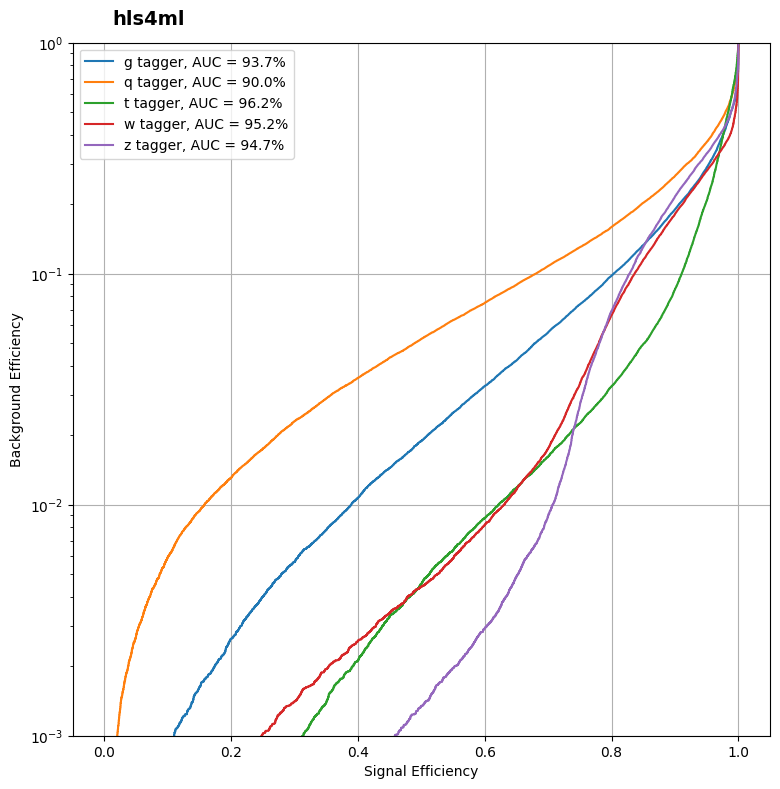

In [11]:
import plotting
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

y_keras = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, le.classes_)

# Quantization Aware Training

Now we train a new model using Quantization Aware Training via `QKeras`.

We replace layers like `Dense` and `Activation` with `QDense` and `QActivation`, and specifiy quantizers to use for the weights, biases and activations.

Notice that the model is still a `Keras` model, and the last layer is a regular `Keras` `Softmax` layer. In general you can mix-and-match normal `Keras` layers with `QKeras` ones.

In [12]:
from qkeras.qlayers import QDense, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

In [35]:
qmodel = Sequential()
qmodel.add(
    QDense(
        64,
        input_shape=(16,),
        name='fc1',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001),
    )
)
qmodel.add(QActivation(activation=quantized_relu(6), name='relu1'))
qmodel.add(
    QDense(
        32,
        name='fc2',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001),
    )
)
qmodel.add(QActivation(activation=quantized_relu(6), name='relu2'))
qmodel.add(
    QDense(
        32,
        name='fc3',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001),
    )
)
qmodel.add(QActivation(activation=quantized_relu(6), name='relu3'))
qmodel.add(
    QDense(
        5,
        name='output',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001),
    )
)
qmodel.add(Activation(activation='softmax', name='softmax'))

In [36]:
train = True
if train:
    adam = Adam(lr=0.0001)
    qmodel.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])
    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='model_3',
    )
    qmodel.fit(
        X_train_val,
        y_train_val,
        batch_size=1024,
        epochs=30,
        validation_split=0.25,
        shuffle=True,
        callbacks=callbacks.callbacks,
    )
    model.save('qmodel_1/KERAS_check_best_model.h5')
else:
    from tensorflow.keras.models import load_model
    from qkeras.utils import _add_supported_quantized_objects

    co = {}
    _add_supported_quantized_objects(co)
    model = load_model('qmodel_1/KERAS_check_best_model.h5', custom_objects=co)

Epoch 1/30


/home/sioni/miniforge3/envs/uzh2025/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


  1/487 [..............................] - ETA: 7:24 - loss: 1.7248 - accuracy: 0.1875WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0020s vs `on_train_batch_end` time: 0.0023s). Check your callbacks.


471/487 [============================>.] - ETA: 0s - loss: 0.9801 - accuracy: 0.6889
***callbacks***
saving losses to model_3/losses.log

Epoch 1: val_loss improved from inf to 0.82131, saving model to model_3/KERAS_check_best_model.h5

Epoch 1: val_loss improved from inf to 0.82131, saving model to model_3/KERAS_check_best_model_weights.h5

Epoch 1: saving model to model_3/KERAS_check_model_last.h5

Epoch 1: saving model to model_3/KERAS_check_model_last_weights.h5

***callbacks end***

487/487 [==============================] - 3s 4ms/step - loss: 0.9749 - accuracy: 0.6904 - val_loss: 0.8213 - val_accuracy: 0.7341 - lr: 0.0010
Epoch 2/30
 74/487 [===>..........................] - ETA: 0s - loss: 0.8069 - accuracy: 0.7382

/home/sioni/miniforge3/envs/uzh2025/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


470/487 [===========================>..] - ETA: 0s - loss: 0.7833 - accuracy: 0.7447
***callbacks***
saving losses to model_3/losses.log

Epoch 2: val_loss improved from 0.82131 to 0.76894, saving model to model_3/KERAS_check_best_model.h5

Epoch 2: val_loss improved from 0.82131 to 0.76894, saving model to model_3/KERAS_check_best_model_weights.h5

Epoch 2: saving model to model_3/KERAS_check_model_last.h5

Epoch 2: saving model to model_3/KERAS_check_model_last_weights.h5

***callbacks end***

487/487 [==============================] - 1s 3ms/step - loss: 0.7825 - accuracy: 0.7449 - val_loss: 0.7689 - val_accuracy: 0.7490 - lr: 0.0010
Epoch 3/30
467/487 [===========================>..] - ETA: 0s - loss: 0.7513 - accuracy: 0.7530
***callbacks***
saving losses to model_3/losses.log

Epoch 3: val_loss improved from 0.76894 to 0.74872, saving model to model_3/KERAS_check_best_model.h5

Epoch 3: val_loss improved from 0.76894 to 0.74872, saving model to model_3/KERAS_check_best_model_weig

## Compare

Plot the ROC curve of the QKeras model alongside the Keras model we trained earlier, and print the accuracy of both. If we chose appropriate quantization, they should perform quite similarly 🤞

5188/5188 [==============================] - 9s 2ms/step
Accuracy Keras:  0.7606325301204819
Accuracy QKeras: 0.7626385542168674


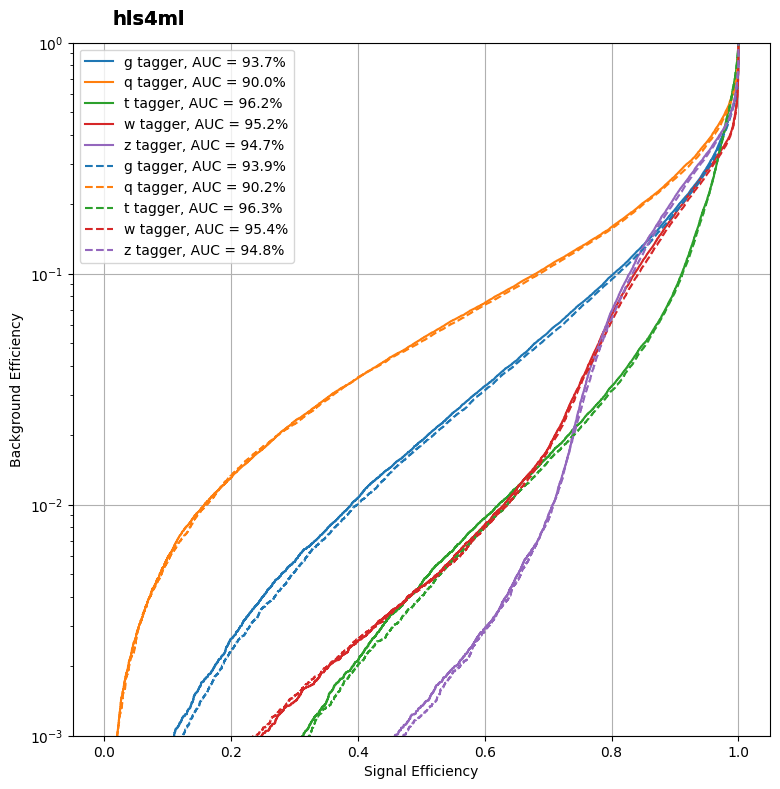

In [37]:
y_qkeras = qmodel.predict(X_test)

print("Accuracy Keras:  {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
print("Accuracy QKeras: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_qkeras, axis=1))))

plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, le.classes_)
plt.gca().set_prop_cycle(None)  # reset the colors
_ = plotting.makeRoc(y_test, y_qkeras, le.classes_, linestyle='--')

In [38]:
import hls4ml

In [42]:
config = hls4ml.utils.config_from_keras_model(qmodel, granularity='name', backend='Vitis', default_precision='fixed<16,7>')
config['LayerName']['output']['Precision']['result'] = 'fixed<16,6,RND,SAT>'
config['LayerName']['softmax']['exp_table_t'] = 'ap_fixed<18,8>'
config['LayerName']['softmax']['inv_table_t'] = 'ap_fixed<18,4>'
print("-----------------------------------")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='qmodel_1/hls4ml_prj', part='xcu250-figd2104-2L-e'
)
hls_model.compile()

/home/sioni/miniforge3/envs/uzh2025/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


-----------------------------------
Model
  Precision
    default:         fixed<16,7>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  fc1_input
    Trace:           False
    Precision
      result:        auto
  fc1
    Trace:           False
    Precision
      result:        auto
      weight:        fixed<6,1,TRN,WRAP,0>
      bias:          fixed<6,1,TRN,WRAP,0>
      accum:         auto
    ReuseFactor:     1
  fc1_linear
    Trace:           False
    Precision
      result:        auto
      table:         fixed<18,8,TRN,WRAP,0>
    ReuseFactor:     1
    TableSize:       1024
  relu1
    Trace:           False
    Precision
      result:        ufixed<6,0,RND_CONV,SAT,0>
      table:         fixed<18,8,TRN,WRAP,0>
    ReuseFactor:     1
    TableSize:       1024
  fc2
    Trace:           False
    Precision
      result:        auto
      weight:        fixed<6,1,TRN,WRAP,0>
      bias:          fixed

In [43]:
y_hls4ml = hls_model.predict(np.ascontiguousarray(X_test))

Accuracy Keras:  0.7606325301204819
Accuracy QKeras: 0.7626385542168674
Accuracy hls4ml: 0.4263614457831325


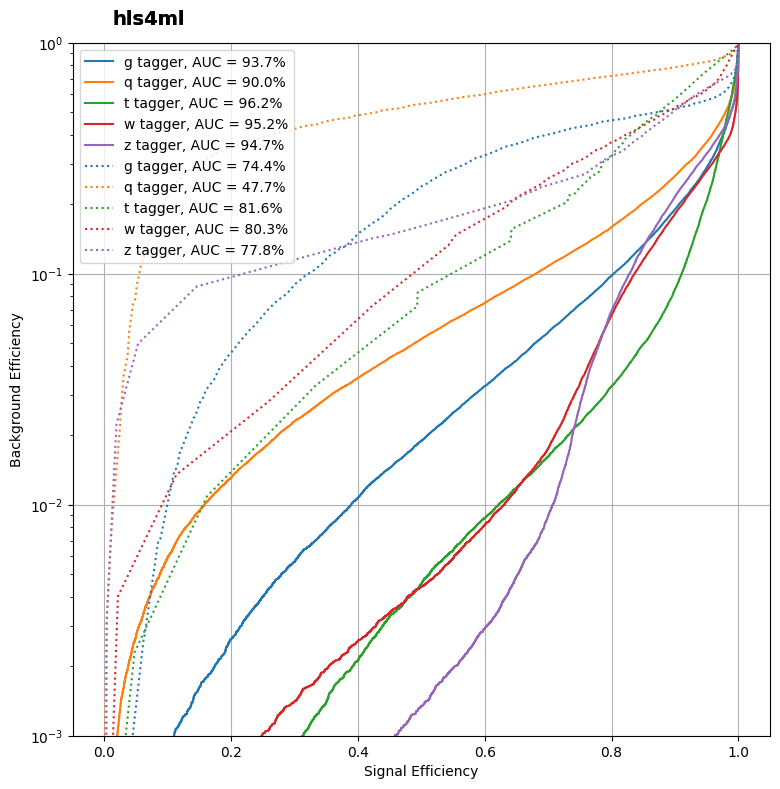

In [44]:
print("Accuracy Keras:  {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
print("Accuracy QKeras: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_qkeras, axis=1))))
print("Accuracy hls4ml: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls4ml, axis=1))))


plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, le.classes_)
plt.gca().set_prop_cycle(None)  # reset the colors
#_ = plotting.makeRoc(y_test, y_qkeras, le.classes_, linestyle='--')
plt.gca().set_prop_cycle(None)  # reset the colors
_ = plotting.makeRoc(y_test, y_hls4ml, le.classes_, linestyle=':')